In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import os
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
# 원본 데이터가 들어 있는 폴더
folder_path = (
    "/content/drive/MyDrive/"
    "원본 데이터/주민등록 1인세대수/전처리_결과"
)

# 전체 주민등록인구·세대수 파일
household_path = (
    f"{folder_path}/전국_세대현황.csv"
)

# 2023~2025 청년 1인세대수 전처리 파일
youth_path = (
    f"{folder_path}/"
    "2023_2025_서울시_행정동별_청년1인세대수.csv"
)

print("전체 세대현황 파일:", household_path)
print("청년 1인세대 파일:", youth_path)

전체 세대현황 파일: /content/drive/MyDrive/원본 데이터/주민등록 1인세대수/전처리_결과/전국_세대현황.csv
청년 1인세대 파일: /content/drive/MyDrive/원본 데이터/주민등록 1인세대수/전처리_결과/2023_2025_서울시_행정동별_청년1인세대수.csv


In [5]:
print("전체 세대현황 파일 존재:", os.path.exists(household_path))
print("청년 1인세대 파일 존재:", os.path.exists(youth_path))

if not os.path.exists(household_path):
    raise FileNotFoundError(
        f"파일을 찾을 수 없습니다: {household_path}"
    )

if not os.path.exists(youth_path):
    raise FileNotFoundError(
        f"파일을 찾을 수 없습니다: {youth_path}"
    )

전체 세대현황 파일 존재: True
청년 1인세대 파일 존재: True


In [6]:
# 전국 세대현황 파일
# 기존 노트북에서 cp949로 정상적으로 읽혔음
household_raw = pd.read_csv(
    household_path,
    encoding="cp949",
    low_memory=False
)

# 청년 1인세대수 파일
youth_raw = pd.read_csv(
    youth_path,
    encoding="utf-8-sig",
    low_memory=False
)

print("세대현황 데이터 크기:", household_raw.shape)
print("청년 1인세대 데이터 크기:", youth_raw.shape)

display(household_raw.head())
display(youth_raw.head())

세대현황 데이터 크기: (4207, 19)
청년 1인세대 데이터 크기: (1279, 13)


,행정구역,2023년_거주자 인구수,2023년_세대수,2023년_세대당 인구,2023년_남자 인구수,2023년_여자 인구수,2023년_남여 비율,2024년_거주자 인구수,2024년_세대수,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율,2025년_거주자 인구수,2025년_세대수,2025년_세대당 인구,2025년_남자 인구수,2025년_여자 인구수,2025년_남여 비율
0,서울특별시 (1100000000),"9,314,535","4,418,098",2.11,"4,503,033","4,811,502",0.94,"9,261,703","4,431,986",2.09,"4,469,100","4,792,603",0.93,"9,232,888","4,453,779",2.07,"4,446,962","4,785,926",0.93
1,서울특별시 종로구 (1111000000),"137,565","70,712",1.95,"66,321","71,244",0.93,"136,624","70,923",1.93,"65,656","70,968",0.93,"135,377","71,112",1.90,"64,797","70,580",0.92
2,서울특별시 종로구 청운효자동(1111051500),"11,221","4,967",2.26,"5,128","6,093",0.84,"10,910","4,883",2.23,"4,970","5,940",0.84,"10,767","4,807",2.24,"4,856","5,911",0.82
3,서울특별시 종로구 사직동(1111053000),"8,847","4,436",1.99,"3,929","4,918",0.80,"8,816","4,461",1.98,"3,897","4,919",0.79,"8,753","4,489",1.95,"3,833","4,920",0.78
4,서울특별시 종로구 삼청동(1111054000),"2,214","1,097",2.02,"1,056","1,158",0.91,"2,187","1,087",2.01,"1,046","1,141",0.92,"2,078","1,042",1.99,985,"1,093",0.90


,연도,행정기관코드,시도,자치구,행정동,총거주자수,총연령구간세대수,20~24세,25~29세,30~34세,35~39세,청년1인세대수,합계차이
0,2023,1111051500,서울특별시,종로구,청운효자동,1898,683.0,49,185,263,186,683,0.0
1,2023,1111053000,서울특별시,종로구,사직동,2225,930.0,58,246,389,237,930,0.0
2,2023,1111054000,서울특별시,종로구,삼청동,537,158.0,13,53,54,38,158,0.0
3,2023,1111055000,서울특별시,종로구,부암동,1600,552.0,77,132,186,157,552,0.0
4,2023,1111056000,서울특별시,종로구,평창동,2140,569.0,63,125,194,187,569,0.0


In [7]:
print("세대현황 컬럼")
print(household_raw.columns.tolist())

print("\n청년 1인세대 컬럼")
print(youth_raw.columns.tolist())

세대현황 컬럼
['행정구역', '2023년_거주자 인구수', '2023년_세대수', '2023년_세대당 인구', '2023년_남자 인구수', '2023년_여자 인구수', '2023년_남여 비율', '2024년_거주자 인구수', '2024년_세대수', '2024년_세대당 인구', '2024년_남자 인구수', '2024년_여자 인구수', '2024년_남여 비율', '2025년_거주자 인구수', '2025년_세대수', '2025년_세대당 인구', '2025년_남자 인구수', '2025년_여자 인구수', '2025년_남여 비율']

청년 1인세대 컬럼
['연도', '행정기관코드', '시도', '자치구', '행정동', '총거주자수', '총연령구간세대수', '20~24세', '25~29세', '30~34세', '35~39세', '청년1인세대수', '합계차이']


In [8]:
required_household_cols = [
    "행정구역",
    "2023년_거주자 인구수",
    "2023년_세대수",
    "2024년_거주자 인구수",
    "2024년_세대수",
    "2025년_거주자 인구수",
    "2025년_세대수"
]

required_youth_cols = [
    "연도",
    "행정기관코드",
    "시도",
    "자치구",
    "행정동",
    "총거주자수",
    "총연령구간세대수",
    "20~24세",
    "25~29세",
    "30~34세",
    "35~39세",
    "청년1인세대수",
    "합계차이"
]

missing_household_cols = [
    col for col in required_household_cols
    if col not in household_raw.columns
]

missing_youth_cols = [
    col for col in required_youth_cols
    if col not in youth_raw.columns
]

print("세대현황 누락 컬럼:", missing_household_cols)
print("청년 파일 누락 컬럼:", missing_youth_cols)

if missing_household_cols:
    raise ValueError(
        f"세대현황 누락 컬럼: {missing_household_cols}"
    )

if missing_youth_cols:
    raise ValueError(
        f"청년 파일 누락 컬럼: {missing_youth_cols}"
    )

print("✅ 필수 컬럼 확인 완료")

세대현황 누락 컬럼: []
청년 파일 누락 컬럼: []
✅ 필수 컬럼 확인 완료


In [9]:
seoul_household = household_raw[
    household_raw["행정구역"]
    .astype(str)
    .str.startswith("서울특별시")
].copy()

print("서울특별시 관련 행 수:", len(seoul_household))

display(
    seoul_household[
        [
            "행정구역",
            "2023년_거주자 인구수",
            "2023년_세대수"
        ]
    ].head(20)
)

서울특별시 관련 행 수: 454


,행정구역,2023년_거주자 인구수,2023년_세대수
0,서울특별시 (1100000000),"9,314,535","4,418,098"
1,서울특별시 종로구 (1111000000),"137,565","70,712"
2,서울특별시 종로구 청운효자동(1111051500),"11,221","4,967"
3,서울특별시 종로구 사직동(1111053000),"8,847","4,436"
4,서울특별시 종로구 삼청동(1111054000),"2,214","1,097"
5,서울특별시 종로구 부암동(1111055000),"8,956","4,038"
6,서울특별시 종로구 평창동(1111056000),"17,093","6,972"
7,서울특별시 종로구 무악동(1111057000),"7,929","2,990"
8,서울특별시 종로구 교남동(1111058000),"9,637","4,289"
9,서울특별시 종로구 가회동(1111060000),"3,756","1,829"


In [10]:
# 괄호 안 10자리 행정기관코드 추출
seoul_household["행정기관코드"] = (
    seoul_household["행정구역"]
    .astype(str)
    .str.extract(r"\((\d{10})\)")
)

# 행정기관코드를 제외한 지역명
seoul_household["행정구역명"] = (
    seoul_household["행정구역"]
    .astype(str)
    .str.replace(
        r"\s*\(\d{10}\)\s*",
        "",
        regex=True
    )
    .str.strip()
)

# 공백 기준 지역 단계 수
seoul_household["지역단계수"] = (
    seoul_household["행정구역명"]
    .str.split()
    .str.len()
)

display(
    seoul_household[
        [
            "행정구역",
            "행정기관코드",
            "행정구역명",
            "지역단계수"
        ]
    ].head(20)
)

,행정구역,행정기관코드,행정구역명,지역단계수
0,서울특별시 (1100000000),1100000000,서울특별시,1
1,서울특별시 종로구 (1111000000),1111000000,서울특별시 종로구,2
2,서울특별시 종로구 청운효자동(1111051500),1111051500,서울특별시 종로구 청운효자동,3
3,서울특별시 종로구 사직동(1111053000),1111053000,서울특별시 종로구 사직동,3
4,서울특별시 종로구 삼청동(1111054000),1111054000,서울특별시 종로구 삼청동,3
5,서울특별시 종로구 부암동(1111055000),1111055000,서울특별시 종로구 부암동,3
6,서울특별시 종로구 평창동(1111056000),1111056000,서울특별시 종로구 평창동,3
7,서울특별시 종로구 무악동(1111057000),1111057000,서울특별시 종로구 무악동,3
8,서울특별시 종로구 교남동(1111058000),1111058000,서울특별시 종로구 교남동,3
9,서울특별시 종로구 가회동(1111060000),1111060000,서울특별시 종로구 가회동,3


In [11]:
seoul_dong = seoul_household[
    seoul_household["지역단계수"] == 3
].copy()

seoul_dong["시도"] = (
    seoul_dong["행정구역명"]
    .str.split()
    .str[0]
)

seoul_dong["자치구"] = (
    seoul_dong["행정구역명"]
    .str.split()
    .str[1]
)

seoul_dong["행정동"] = (
    seoul_dong["행정구역명"]
    .str.split()
    .str[2]
)

print("서울 행정동 행 수:", len(seoul_dong))

display(
    seoul_dong[
        [
            "행정기관코드",
            "시도",
            "자치구",
            "행정동"
        ]
    ].head(20)
)

서울 행정동 행 수: 428


,행정기관코드,시도,자치구,행정동
2,1111051500,서울특별시,종로구,청운효자동
3,1111053000,서울특별시,종로구,사직동
4,1111054000,서울특별시,종로구,삼청동
5,1111055000,서울특별시,종로구,부암동
6,1111056000,서울특별시,종로구,평창동
7,1111057000,서울특별시,종로구,무악동
8,1111058000,서울특별시,종로구,교남동
9,1111060000,서울특별시,종로구,가회동
10,1111061500,서울특별시,종로구,종로1.2.3.4가동
11,1111063000,서울특별시,종로구,종로5.6가동


In [12]:
household_numeric_cols = [
    "2023년_거주자 인구수",
    "2023년_세대수",
    "2024년_거주자 인구수",
    "2024년_세대수",
    "2025년_거주자 인구수",
    "2025년_세대수"
]

for col in household_numeric_cols:
    seoul_dong[col] = (
        seoul_dong[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace({
            "": np.nan,
            "nan": np.nan,
            "-": np.nan
        })
    )

    seoul_dong[col] = pd.to_numeric(
        seoul_dong[col],
        errors="coerce"
    )

# 행정기관코드는 문자열 10자리로 통일
seoul_dong["행정기관코드"] = (
    seoul_dong["행정기관코드"]
    .astype("string")
    .str.strip()
    .str.zfill(10)
)

print(seoul_dong[household_numeric_cols].dtypes)

display(
    seoul_dong[
        [
            "행정기관코드",
            "자치구",
            "행정동",
            "2023년_거주자 인구수",
            "2023년_세대수",
            "2024년_거주자 인구수",
            "2024년_세대수",
            "2025년_거주자 인구수",
            "2025년_세대수"
        ]
    ].head()
)

2023년_거주자 인구수    float64
2023년_세대수        float64
2024년_거주자 인구수    float64
2024년_세대수        float64
2025년_거주자 인구수    float64
2025년_세대수        float64
dtype: object


,행정기관코드,자치구,행정동,2023년_거주자 인구수,2023년_세대수,2024년_거주자 인구수,2024년_세대수,2025년_거주자 인구수,2025년_세대수
2,1111051500,종로구,청운효자동,11221.0,4967.0,10910.0,4883.0,10767.0,4807.0
3,1111053000,종로구,사직동,8847.0,4436.0,8816.0,4461.0,8753.0,4489.0
4,1111054000,종로구,삼청동,2214.0,1097.0,2187.0,1087.0,2078.0,1042.0
5,1111055000,종로구,부암동,8956.0,4038.0,8926.0,4042.0,8808.0,4024.0
6,1111056000,종로구,평창동,17093.0,6972.0,16985.0,6984.0,16810.0,6943.0


In [13]:
denominator_list = []

for year in [2023, 2024, 2025]:

    temp = seoul_dong[
        [
            "행정기관코드",
            "시도",
            "자치구",
            "행정동",
            f"{year}년_세대수",
            f"{year}년_거주자 인구수"
        ]
    ].copy()

    temp["연도"] = year

    temp = temp.rename(
        columns={
            f"{year}년_세대수": "전체세대수",
            f"{year}년_거주자 인구수": "전체주민등록인구"
        }
    )

    denominator_list.append(temp)

denominator_long = pd.concat(
    denominator_list,
    ignore_index=True
)

denominator_long = denominator_long[
    [
        "연도",
        "행정기관코드",
        "시도",
        "자치구",
        "행정동",
        "전체세대수",
        "전체주민등록인구"
    ]
].copy()

print("연도별 분모 데이터 크기:", denominator_long.shape)

print(
    denominator_long
    .groupby("연도")
    .size()
)

display(denominator_long.head(10))

연도별 분모 데이터 크기: (1284, 7)
연도
2023    428
2024    428
2025    428
dtype: int64


,연도,행정기관코드,시도,자치구,행정동,전체세대수,전체주민등록인구
0,2023,1111051500,서울특별시,종로구,청운효자동,4967.0,11221.0
1,2023,1111053000,서울특별시,종로구,사직동,4436.0,8847.0
2,2023,1111054000,서울특별시,종로구,삼청동,1097.0,2214.0
3,2023,1111055000,서울특별시,종로구,부암동,4038.0,8956.0
4,2023,1111056000,서울특별시,종로구,평창동,6972.0,17093.0
5,2023,1111057000,서울특별시,종로구,무악동,2990.0,7929.0
6,2023,1111058000,서울특별시,종로구,교남동,4289.0,9637.0
7,2023,1111060000,서울특별시,종로구,가회동,1829.0,3756.0
8,2023,1111061500,서울특별시,종로구,종로1.2.3.4가동,4719.0,6470.0
9,2023,1111063000,서울특별시,종로구,종로5.6가동,3504.0,5293.0


In [14]:
youth = youth_raw.copy()

# 연도
youth["연도"] = pd.to_numeric(
    youth["연도"],
    errors="coerce"
).astype("Int64")

# 행정기관코드
youth["행정기관코드"] = (
    youth["행정기관코드"]
    .astype("string")
    .str.replace(r"\.0$", "", regex=True)
    .str.strip()
    .str.zfill(10)
)

youth_numeric_cols = [
    "총거주자수",
    "총연령구간세대수",
    "20~24세",
    "25~29세",
    "30~34세",
    "35~39세",
    "청년1인세대수",
    "합계차이"
]

for col in youth_numeric_cols:
    youth[col] = (
        youth[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace({
            "": np.nan,
            "nan": np.nan,
            "-": np.nan
        })
    )

    youth[col] = pd.to_numeric(
        youth[col],
        errors="coerce"
    )

# 필요한 연도만 남기기
youth = youth[
    youth["연도"].isin([2023, 2024, 2025])
].copy()

display(youth.head(10))
print(youth.dtypes)

,연도,행정기관코드,시도,자치구,행정동,총거주자수,총연령구간세대수,20~24세,25~29세,30~34세,35~39세,청년1인세대수,합계차이
0,2023,1111051500,서울특별시,종로구,청운효자동,1898,683.0,49,185,263,186,683,0.0
1,2023,1111053000,서울특별시,종로구,사직동,2225,930.0,58,246,389,237,930,0.0
2,2023,1111054000,서울특별시,종로구,삼청동,537,158.0,13,53,54,38,158,0.0
3,2023,1111055000,서울특별시,종로구,부암동,1600,552.0,77,132,186,157,552,0.0
4,2023,1111056000,서울특별시,종로구,평창동,2140,569.0,63,125,194,187,569,0.0
5,2023,1111057000,서울특별시,종로구,무악동,691,105.0,4,13,50,38,105,0.0
6,2023,1111058000,서울특별시,종로구,교남동,1575,560.0,38,187,201,134,560,0.0
7,2023,1111060000,서울특별시,종로구,가회동,854,267.0,17,62,113,75,267,0.0
8,2023,1111061500,서울특별시,종로구,종로1.2.3.4가동,3747,1241.0,161,491,373,216,1241,0.0
9,2023,1111063000,서울특별시,종로구,종로5.6가동,2501,1313.0,257,550,352,154,1313,0.0


연도                   Int64
행정기관코드      string[python]
시도                  object
자치구                 object
행정동                 object
총거주자수                int64
총연령구간세대수           float64
20~24세               int64
25~29세               int64
30~34세               int64
35~39세               int64
청년1인세대수              int64
합계차이               float64
dtype: object


In [15]:
youth["청년1인세대수_재계산"] = (
    youth["20~24세"]
    + youth["25~29세"]
    + youth["30~34세"]
    + youth["35~39세"]
)

youth["청년1인세대수_재계산차이"] = (
    youth["청년1인세대수"]
    - youth["청년1인세대수_재계산"]
)

print(
    "청년 1인세대수 재계산 불일치 행 수:",
    (
        youth["청년1인세대수_재계산차이"] != 0
    ).sum()
)

display(
    youth[
        youth["청년1인세대수_재계산차이"] != 0
    ][
        [
            "연도",
            "행정기관코드",
            "자치구",
            "행정동",
            "20~24세",
            "25~29세",
            "30~34세",
            "35~39세",
            "청년1인세대수",
            "청년1인세대수_재계산",
            "청년1인세대수_재계산차이"
        ]
    ]
)

청년 1인세대수 재계산 불일치 행 수: 0


,연도,행정기관코드,자치구,행정동,20~24세,25~29세,30~34세,35~39세,청년1인세대수,청년1인세대수_재계산,청년1인세대수_재계산차이


In [16]:
print("합계차이 값 분포")

display(
    youth["합계차이"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
    .rename(
        columns={
            "index": "합계차이",
            "합계차이": "행수"
        }
    )
)

합계차이 값 분포


,행수,count
0,0.0,1279


In [17]:
youth_duplicates = youth[
    youth.duplicated(
        subset=[
            "연도",
            "행정기관코드"
        ],
        keep=False
    )
].copy()

denominator_duplicates = denominator_long[
    denominator_long.duplicated(
        subset=[
            "연도",
            "행정기관코드"
        ],
        keep=False
    )
].copy()

print("청년 파일 중복 행 수:", len(youth_duplicates))
print("세대현황 중복 행 수:", len(denominator_duplicates))

if len(youth_duplicates) > 0:
    display(
        youth_duplicates.sort_values(
            [
                "연도",
                "행정기관코드"
            ]
        )
    )

if len(denominator_duplicates) > 0:
    display(
        denominator_duplicates.sort_values(
            [
                "연도",
                "행정기관코드"
            ]
        )
    )

청년 파일 중복 행 수: 0
세대현황 중복 행 수: 0


In [18]:
if len(youth_duplicates) > 0:
    raise ValueError(
        "청년 1인세대 파일에 연도·행정기관코드 중복이 있습니다."
    )

if len(denominator_duplicates) > 0:
    raise ValueError(
        "세대현황 파일에 연도·행정기관코드 중복이 있습니다."
    )

print("✅ 중복 검증 통과")

✅ 중복 검증 통과


In [19]:
merged = youth.merge(
    denominator_long[
        [
            "연도",
            "행정기관코드",
            "전체세대수",
            "전체주민등록인구"
        ]
    ],
    on=[
        "연도",
        "행정기관코드"
    ],
    how="left",
    validate="one_to_one"
)

print("병합 전 행 수:", len(youth))
print("병합 후 행 수:", len(merged))

print(
    "전체세대수 병합 실패:",
    merged["전체세대수"].isna().sum()
)

print(
    "전체주민등록인구 병합 실패:",
    merged["전체주민등록인구"].isna().sum()
)

display(
    merged[
        [
            "연도",
            "행정기관코드",
            "자치구",
            "행정동",
            "총거주자수",
            "전체주민등록인구",
            "전체세대수",
            "청년1인세대수"
        ]
    ].head(20)
)

병합 전 행 수: 1279
병합 후 행 수: 1279
전체세대수 병합 실패: 0
전체주민등록인구 병합 실패: 0


,연도,행정기관코드,자치구,행정동,총거주자수,전체주민등록인구,전체세대수,청년1인세대수
0,2023,1111051500,종로구,청운효자동,1898,11221.0,4967.0,683
1,2023,1111053000,종로구,사직동,2225,8847.0,4436.0,930
2,2023,1111054000,종로구,삼청동,537,2214.0,1097.0,158
3,2023,1111055000,종로구,부암동,1600,8956.0,4038.0,552
4,2023,1111056000,종로구,평창동,2140,17093.0,6972.0,569
5,2023,1111057000,종로구,무악동,691,7929.0,2990.0,105
6,2023,1111058000,종로구,교남동,1575,9637.0,4289.0,560
7,2023,1111060000,종로구,가회동,854,3756.0,1829.0,267
8,2023,1111061500,종로구,종로1.2.3.4가동,3747,6470.0,4719.0,1241
9,2023,1111063000,종로구,종로5.6가동,2501,5293.0,3504.0,1313


In [20]:
merge_failed = merged[
    merged["전체세대수"].isna()
    | merged["전체주민등록인구"].isna()
].copy()

print("병합 실패 행 수:", len(merge_failed))

display(
    merge_failed[
        [
            "연도",
            "행정기관코드",
            "시도",
            "자치구",
            "행정동",
            "청년1인세대수",
            "전체세대수",
            "전체주민등록인구"
        ]
    ]
)

병합 실패 행 수: 0


,연도,행정기관코드,시도,자치구,행정동,청년1인세대수,전체세대수,전체주민등록인구


In [21]:
# ============================================
# 총거주자수 컬럼 의미 확인
# ============================================

print("청년 파일 총거주자수 기초통계")
display(
    merged["총거주자수"].describe()
)

print("\n세대현황 전체주민등록인구 기초통계")
display(
    merged["전체주민등록인구"].describe()
)

print(
    "\n주의: 두 컬럼은 값의 규모가 크게 달라 "
    "동일한 전체 인구 변수로 간주하지 않습니다."
)

display(
    merged[
        [
            "연도",
            "행정기관코드",
            "자치구",
            "행정동",
            "총거주자수",
            "전체주민등록인구",
            "전체세대수",
            "청년1인세대수"
        ]
    ].head(20)
)

청년 파일 총거주자수 기초통계


,총거주자수
count,1279.000000
mean,4614.503518
std,2903.534120
min,7.000000
25%,2500.000000
50%,4014.000000
75%,5879.000000
max,18063.000000



세대현황 전체주민등록인구 기초통계


,전체주민등록인구
count,1279.000000
mean,21742.866302
std,8979.130336
min,19.000000
25%,15785.500000
50%,21029.000000
75%,27055.500000
max,54101.000000



주의: 두 컬럼은 값의 규모가 크게 달라 동일한 전체 인구 변수로 간주하지 않습니다.


,연도,행정기관코드,자치구,행정동,총거주자수,전체주민등록인구,전체세대수,청년1인세대수
0,2023,1111051500,종로구,청운효자동,1898,11221.0,4967.0,683
1,2023,1111053000,종로구,사직동,2225,8847.0,4436.0,930
2,2023,1111054000,종로구,삼청동,537,2214.0,1097.0,158
3,2023,1111055000,종로구,부암동,1600,8956.0,4038.0,552
4,2023,1111056000,종로구,평창동,2140,17093.0,6972.0,569
5,2023,1111057000,종로구,무악동,691,7929.0,2990.0,105
6,2023,1111058000,종로구,교남동,1575,9637.0,4289.0,560
7,2023,1111060000,종로구,가회동,854,3756.0,1829.0,267
8,2023,1111061500,종로구,종로1.2.3.4가동,3747,6470.0,4719.0,1241
9,2023,1111063000,종로구,종로5.6가동,2501,5293.0,3504.0,1313


In [22]:
# ============================================
# 청년 1인세대 관련 파생변수 계산
# ============================================

# 1. 전체 세대 중 청년 1인세대 비율
merged["전체세대대비_청년1인세대비율"] = np.where(
    merged["전체세대수"] > 0,
    merged["청년1인세대수"]
    / merged["전체세대수"]
    * 100,
    np.nan
)

# 2. 전체 주민등록인구 중 청년 1인세대 비율
merged["전체인구대비_청년1인세대비율"] = np.where(
    merged["전체주민등록인구"] > 0,
    merged["청년1인세대수"]
    / merged["전체주민등록인구"]
    * 100,
    np.nan
)

# 3. 전체 1인세대 중 청년 1인세대 비율
merged["전체1인세대대비_청년1인세대비율"] = np.where(
    merged["총거주자수"] > 0,
    merged["청년1인세대수"]
    / merged["총거주자수"]
    * 100,
    np.nan
)

ratio_cols = [
    "전체세대대비_청년1인세대비율",
    "전체인구대비_청년1인세대비율",
    "전체1인세대대비_청년1인세대비율"
]

for col in ratio_cols:
    merged[col] = merged[col].round(2)

display(
    merged[
        [
            "연도",
            "자치구",
            "행정동",
            "전체세대수",
            "전체주민등록인구",
            "총거주자수",
            "청년1인세대수",
            "전체세대대비_청년1인세대비율",
            "전체인구대비_청년1인세대비율",
            "전체1인세대대비_청년1인세대비율"
        ]
    ].head(20)
)

,연도,자치구,행정동,전체세대수,전체주민등록인구,총거주자수,청년1인세대수,전체세대대비_청년1인세대비율,전체인구대비_청년1인세대비율,전체1인세대대비_청년1인세대비율
0,2023,종로구,청운효자동,4967.0,11221.0,1898,683,13.75,6.09,35.99
1,2023,종로구,사직동,4436.0,8847.0,2225,930,20.96,10.51,41.80
2,2023,종로구,삼청동,1097.0,2214.0,537,158,14.40,7.14,29.42
3,2023,종로구,부암동,4038.0,8956.0,1600,552,13.67,6.16,34.50
4,2023,종로구,평창동,6972.0,17093.0,2140,569,8.16,3.33,26.59
5,2023,종로구,무악동,2990.0,7929.0,691,105,3.51,1.32,15.20
6,2023,종로구,교남동,4289.0,9637.0,1575,560,13.06,5.81,35.56
7,2023,종로구,가회동,1829.0,3756.0,854,267,14.60,7.11,31.26
8,2023,종로구,종로1.2.3.4가동,4719.0,6470.0,3747,1241,26.30,19.18,33.12
9,2023,종로구,종로5.6가동,3504.0,5293.0,2501,1313,37.47,24.81,52.50


In [23]:
# ============================================
# 비율 범위 및 논리 오류 검증
# ============================================

logic_error_mask = (
    (merged["전체세대수"] <= 0)
    | (merged["전체주민등록인구"] <= 0)
    | (merged["총거주자수"] <= 0)
    | (merged["청년1인세대수"] < 0)
    | (
        merged["청년1인세대수"]
        > merged["전체세대수"]
    )
    | (
        merged["청년1인세대수"]
        > merged["전체주민등록인구"]
    )
    | (
        merged["청년1인세대수"]
        > merged["총거주자수"]
    )
    | (
        merged["전체세대대비_청년1인세대비율"]
        .notna()
        & (
            (
                merged[
                    "전체세대대비_청년1인세대비율"
                ] < 0
            )
            | (
                merged[
                    "전체세대대비_청년1인세대비율"
                ] > 100
            )
        )
    )
    | (
        merged["전체인구대비_청년1인세대비율"]
        .notna()
        & (
            (
                merged[
                    "전체인구대비_청년1인세대비율"
                ] < 0
            )
            | (
                merged[
                    "전체인구대비_청년1인세대비율"
                ] > 100
            )
        )
    )
    | (
        merged["전체1인세대대비_청년1인세대비율"]
        .notna()
        & (
            (
                merged[
                    "전체1인세대대비_청년1인세대비율"
                ] < 0
            )
            | (
                merged[
                    "전체1인세대대비_청년1인세대비율"
                ] > 100
            )
        )
    )
)

logic_errors = merged[
    logic_error_mask
].copy()

print("논리 오류 행 수:", len(logic_errors))

display(
    logic_errors[
        [
            "연도",
            "행정기관코드",
            "자치구",
            "행정동",
            "전체세대수",
            "전체주민등록인구",
            "총거주자수",
            "청년1인세대수",
            "전체세대대비_청년1인세대비율",
            "전체인구대비_청년1인세대비율",
            "전체1인세대대비_청년1인세대비율"
        ]
    ]
)

논리 오류 행 수: 0


,연도,행정기관코드,자치구,행정동,전체세대수,전체주민등록인구,총거주자수,청년1인세대수,전체세대대비_청년1인세대비율,전체인구대비_청년1인세대비율,전체1인세대대비_청년1인세대비율


In [24]:
# ============================================
# 연도별 청년 1인세대수 하위 5% 표시
# ============================================

merged["청년1인세대수_연도별하위5퍼기준"] = (
    merged.groupby("연도")["청년1인세대수"]
    .transform(
        lambda x: x.quantile(0.05)
    )
)

merged["저표본_여부"] = np.where(
    merged["청년1인세대수"]
    <= merged["청년1인세대수_연도별하위5퍼기준"],
    "주의",
    "일반"
)

display(
    merged.groupby(
        [
            "연도",
            "저표본_여부"
        ]
    )
    .size()
    .reset_index(name="행정동수")
)

,연도,저표본_여부,행정동수
0,2023,일반,404
1,2023,주의,22
2,2024,일반,404
3,2024,주의,22
4,2025,일반,405
5,2025,주의,22


In [25]:
# ============================================
# 연도별 최종 데이터
# ============================================

final_yearly = merged[
    [
        "연도",
        "행정기관코드",
        "시도",
        "자치구",
        "행정동",

        "전체세대수",
        "전체주민등록인구",
        "총거주자수",

        "20~24세",
        "25~29세",
        "30~34세",
        "35~39세",
        "청년1인세대수",

        "전체세대대비_청년1인세대비율",
        "전체인구대비_청년1인세대비율",
        "전체1인세대대비_청년1인세대비율",

        "청년1인세대수_연도별하위5퍼기준",
        "저표본_여부",

        "총연령구간세대수",
        "합계차이"
    ]
].copy()

final_yearly = (
    final_yearly
    .sort_values(
        [
            "연도",
            "자치구",
            "행정동",
            "행정기관코드"
        ]
    )
    .reset_index(drop=True)
)

print("연도별 최종 데이터 크기:", final_yearly.shape)

display(final_yearly.head(20))

연도별 최종 데이터 크기: (1279, 20)


,연도,행정기관코드,시도,자치구,행정동,전체세대수,전체주민등록인구,총거주자수,20~24세,25~29세,30~34세,35~39세,청년1인세대수,전체세대대비_청년1인세대비율,전체인구대비_청년1인세대비율,전체1인세대대비_청년1인세대비율,청년1인세대수_연도별하위5퍼기준,저표본_여부,총연령구간세대수,합계차이
0,2023,1168066000,서울특별시,강남구,개포1동,4283.0,11753.0,868,4,25,47,43,119,2.78,1.01,13.71,313.5,주의,119.0,0.0
1,2023,1168067000,서울특별시,강남구,개포2동,14657.0,41409.0,2461,71,224,384,261,940,6.41,2.27,38.20,313.5,일반,940.0,0.0
2,2023,1168067500,서울특별시,강남구,개포3동,7299.0,16719.0,2481,20,122,266,202,610,8.36,3.65,24.59,313.5,일반,610.0,0.0
3,2023,1168069000,서울특별시,강남구,개포4동,9781.0,22847.0,3466,92,411,541,357,1401,14.32,6.13,40.42,313.5,일반,1401.0,0.0
4,2023,1168052100,서울특별시,강남구,논현1동,13101.0,20503.0,8916,510,1662,1924,1263,5359,40.91,26.14,60.11,313.5,일반,5359.0,0.0
5,2023,1168053100,서울특별시,강남구,논현2동,10874.0,19932.0,6133,267,1092,1216,895,3470,31.91,17.41,56.58,313.5,일반,3470.0,0.0
6,2023,1168060000,서울특별시,강남구,대치1동,7148.0,23759.0,508,18,25,31,28,102,1.43,0.43,20.08,313.5,주의,102.0,0.0
7,2023,1168061000,서울특별시,강남구,대치2동,13090.0,37905.0,2340,102,294,380,235,1011,7.72,2.67,43.21,313.5,일반,1011.0,0.0
8,2023,1168063000,서울특별시,강남구,대치4동,9539.0,18376.0,5213,277,743,1011,649,2680,28.10,14.58,51.41,313.5,일반,2680.0,0.0
9,2023,1168065500,서울특별시,강남구,도곡1동,8071.0,20346.0,2493,81,401,481,298,1261,15.62,6.20,50.58,313.5,일반,1261.0,0.0


In [26]:
# ============================================
# 연도별 요약
# ============================================

yearly_summary = (
    final_yearly
    .groupby("연도")
    .agg(
        행수=("행정기관코드", "size"),
        행정동수=("행정기관코드", "nunique"),

        전체세대수_합계=(
            "전체세대수",
            "sum"
        ),

        전체주민등록인구_합계=(
            "전체주민등록인구",
            "sum"
        ),

        전체1인세대수_합계=(
            "총거주자수",
            "sum"
        ),

        청년1인세대수_합계=(
            "청년1인세대수",
            "sum"
        ),

        전체세대대비비율_평균=(
            "전체세대대비_청년1인세대비율",
            "mean"
        ),

        전체인구대비비율_평균=(
            "전체인구대비_청년1인세대비율",
            "mean"
        ),

        전체1인세대대비비율_평균=(
            "전체1인세대대비_청년1인세대비율",
            "mean"
        ),

        저표본지역수=(
            "저표본_여부",
            lambda x: (x == "주의").sum()
        )
    )
    .reset_index()
)

summary_ratio_cols = [
    "전체세대대비비율_평균",
    "전체인구대비비율_평균",
    "전체1인세대대비비율_평균"
]

for col in summary_ratio_cols:
    yearly_summary[col] = (
        yearly_summary[col].round(2)
    )

display(yearly_summary)

,연도,행수,행정동수,전체세대수_합계,전체주민등록인구_합계,전체1인세대수_합계,청년1인세대수_합계,전체세대대비비율_평균,전체인구대비비율_평균,전체1인세대대비비율_평균,저표본지역수
0,2023,426,426,4418098.0,9314535.0,1944019,895264,18.72,9.97,40.18,22
1,2024,426,426,4431986.0,9261703.0,1968907,902571,18.81,10.12,39.92,22
2,2025,427,427,4453779.0,9232888.0,1989024,898989,18.62,10.12,39.22,22


In [27]:
# ============================================
# 연도별 데이터 분리
# ============================================

final_2023 = (
    final_yearly[
        final_yearly["연도"] == 2023
    ]
    .copy()
    .reset_index(drop=True)
)

final_2024 = (
    final_yearly[
        final_yearly["연도"] == 2024
    ]
    .copy()
    .reset_index(drop=True)
)

final_2025 = (
    final_yearly[
        final_yearly["연도"] == 2025
    ]
    .copy()
    .reset_index(drop=True)
)

print("2023년:", final_2023.shape)
print("2024년:", final_2024.shape)
print("2025년:", final_2025.shape)

2023년: (426, 20)
2024년: (426, 20)
2025년: (427, 20)


In [28]:
# ============================================
# 2023~2025년 통합 집계
# ============================================

final_3years = (
    final_yearly
    .groupby(
        "행정기관코드",
        as_index=False
    )
    .agg(
        시도=("시도", "last"),
        자치구=("자치구", "last"),
        행정동=("행정동", "last"),

        관측연도수=("연도", "nunique"),
        관측시작연도=("연도", "min"),
        관측종료연도=("연도", "max"),

        전체세대수_3개년합계=(
            "전체세대수",
            "sum"
        ),

        전체주민등록인구_3개년합계=(
            "전체주민등록인구",
            "sum"
        ),

        전체1인세대수_3개년합계=(
            "총거주자수",
            "sum"
        ),

        청년1인세대수_3개년합계=(
            "청년1인세대수",
            "sum"
        )
    )
)

display(final_3years.head(10))

,행정기관코드,시도,자치구,행정동,관측연도수,관측시작연도,관측종료연도,전체세대수_3개년합계,전체주민등록인구_3개년합계,전체1인세대수_3개년합계,청년1인세대수_3개년합계
0,1111051500,서울특별시,종로구,청운효자동,3,2023,2025,14657.0,32898.0,5575,1934
1,1111053000,서울특별시,종로구,사직동,3,2023,2025,13386.0,26416.0,6769,2847
2,1111054000,서울특별시,종로구,삼청동,3,2023,2025,3226.0,6479.0,1579,469
3,1111055000,서울특별시,종로구,부암동,3,2023,2025,12104.0,26690.0,4808,1647
4,1111056000,서울특별시,종로구,평창동,3,2023,2025,20899.0,50888.0,6418,1583
5,1111057000,서울특별시,종로구,무악동,3,2023,2025,8901.0,23404.0,2071,297
6,1111058000,서울특별시,종로구,교남동,3,2023,2025,12782.0,28447.0,4746,1651
7,1111060000,서울특별시,종로구,가회동,3,2023,2025,5381.0,10965.0,2527,763
8,1111061500,서울특별시,종로구,종로1.2.3.4가동,3,2023,2025,14160.0,19355.0,11254,3777
9,1111063000,서울특별시,종로구,종로5.6가동,3,2023,2025,10604.0,15840.0,7614,4042


In [29]:
# ============================================
# 3개년 통합 비율
# ============================================

final_3years[
    "전체세대대비_청년1인세대비율_3개년"
] = np.where(
    final_3years["전체세대수_3개년합계"] > 0,
    final_3years["청년1인세대수_3개년합계"]
    / final_3years["전체세대수_3개년합계"]
    * 100,
    np.nan
)

final_3years[
    "전체인구대비_청년1인세대비율_3개년"
] = np.where(
    final_3years[
        "전체주민등록인구_3개년합계"
    ] > 0,
    final_3years["청년1인세대수_3개년합계"]
    / final_3years[
        "전체주민등록인구_3개년합계"
    ]
    * 100,
    np.nan
)

final_3years[
    "전체1인세대대비_청년1인세대비율_3개년"
] = np.where(
    final_3years[
        "전체1인세대수_3개년합계"
    ] > 0,
    final_3years["청년1인세대수_3개년합계"]
    / final_3years[
        "전체1인세대수_3개년합계"
    ]
    * 100,
    np.nan
)

three_year_ratio_cols = [
    "전체세대대비_청년1인세대비율_3개년",
    "전체인구대비_청년1인세대비율_3개년",
    "전체1인세대대비_청년1인세대비율_3개년"
]

for col in three_year_ratio_cols:
    final_3years[col] = (
        final_3years[col].round(2)
    )

In [30]:
# ============================================
# 3개년 자료 상태 표시
# ============================================

final_3years["3개년자료_완전여부"] = np.where(
    final_3years["관측연도수"] == 3,
    "3개년 모두 존재",
    "일부 연도만 존재"
)

three_year_threshold = (
    final_3years[
        "청년1인세대수_3개년합계"
    ]
    .quantile(0.05)
)

final_3years["3개년_저표본_여부"] = np.where(
    final_3years[
        "청년1인세대수_3개년합계"
    ] <= three_year_threshold,
    "주의",
    "일반"
)

final_3years = (
    final_3years
    .sort_values(
        [
            "자치구",
            "행정동",
            "행정기관코드"
        ]
    )
    .reset_index(drop=True)
)

display(final_3years.head(20))

,행정기관코드,시도,자치구,행정동,관측연도수,관측시작연도,관측종료연도,전체세대수_3개년합계,전체주민등록인구_3개년합계,전체1인세대수_3개년합계,청년1인세대수_3개년합계,전체세대대비_청년1인세대비율_3개년,전체인구대비_청년1인세대비율_3개년,전체1인세대대비_청년1인세대비율_3개년,3개년자료_완전여부,3개년_저표본_여부
0,1168066000,서울특별시,강남구,개포1동,3,2023,2025,22347.0,64379.0,3438,581,2.60,0.90,16.90,3개년 모두 존재,주의
1,1168067000,서울특별시,강남구,개포2동,3,2023,2025,44327.0,125298.0,7351,2547,5.75,2.03,34.65,3개년 모두 존재,일반
2,1168067500,서울특별시,강남구,개포3동,3,2023,2025,21630.0,49107.0,7439,1770,8.18,3.60,23.79,3개년 모두 존재,일반
3,1168069000,서울특별시,강남구,개포4동,3,2023,2025,29427.0,68301.0,10449,4179,14.20,6.12,39.99,3개년 모두 존재,일반
4,1168052100,서울특별시,강남구,논현1동,3,2023,2025,38992.0,60790.0,26612,15741,40.37,25.89,59.15,3개년 모두 존재,일반
5,1168053100,서울특별시,강남구,논현2동,3,2023,2025,32538.0,59291.0,18457,10163,31.23,17.14,55.06,3개년 모두 존재,일반
6,1168060000,서울특별시,강남구,대치1동,3,2023,2025,21426.0,71182.0,1480,285,1.33,0.40,19.26,3개년 모두 존재,주의
7,1168061000,서울특별시,강남구,대치2동,3,2023,2025,39419.0,114127.0,6997,2956,7.50,2.59,42.25,3개년 모두 존재,일반
8,1168063000,서울특별시,강남구,대치4동,3,2023,2025,28328.0,54124.0,15530,7947,28.05,14.68,51.17,3개년 모두 존재,일반
9,1168065500,서울특별시,강남구,도곡1동,3,2023,2025,24379.0,61221.0,7534,3835,15.73,6.26,50.90,3개년 모두 존재,일반


In [31]:
# ============================================
# 3개년 완전 자료
# ============================================

final_3years_complete = (
    final_3years[
        final_3years["관측연도수"] == 3
    ]
    .copy()
    .reset_index(drop=True)
)

print("3개년 전체 행 수:", len(final_3years))
print(
    "3개년 모두 존재하는 행 수:",
    len(final_3years_complete)
)

print(
    "일부 연도만 존재하는 행 수:",
    (
        final_3years["관측연도수"] < 3
    ).sum()
)

display(
    final_3years[
        final_3years["관측연도수"] < 3
    ]
)

3개년 전체 행 수: 428
3개년 모두 존재하는 행 수: 425
일부 연도만 존재하는 행 수: 3


,행정기관코드,시도,자치구,행정동,관측연도수,관측시작연도,관측종료연도,전체세대수_3개년합계,전체주민등록인구_3개년합계,전체1인세대수_3개년합계,청년1인세대수_3개년합계,전체세대대비_청년1인세대비율_3개년,전체인구대비_청년1인세대비율_3개년,전체1인세대대비_청년1인세대비율_3개년,3개년자료_완전여부,3개년_저표본_여부
171,1123051500,서울특별시,동대문구,신설동,1,2025,2025,9498.0,16325.0,5771,3434,36.15,21.04,59.50,일부 연도만 존재,일반
172,1123053300,서울특별시,동대문구,용두동,1,2025,2025,12552.0,22374.0,7175,3469,27.64,15.50,48.35,일부 연도만 존재,일반
173,1123053600,서울특별시,동대문구,용신동,2,2023,2024,43133.0,76468.0,25184,13449,31.18,17.59,53.40,일부 연도만 존재,일반


In [32]:
# ============================================
# 최종 분석용 청년 1인세대 비중 지표 저장
# ============================================

# 2023~2025년 자료가 모두 존재하는 행정동만 사용
# 최종 지표:
# 청년 1인세대 비중
# = 3개년 청년 1인세대수 합계
#   ÷ 3개년 전체 세대수 합계 × 100

final_output = final_3years_complete[
    [
        "행정기관코드",
        "시도",
        "자치구",
        "행정동",
        "관측연도수",
        "관측시작연도",
        "관측종료연도",
        "전체세대수_3개년합계",
        "청년1인세대수_3개년합계",
        "전체세대대비_청년1인세대비율_3개년",
        "3개년_저표본_여부"
    ]
].copy()

# 최종 모델에서 사용할 지표명을 간단하게 변경
final_output = final_output.rename(
    columns={
        "전체세대수_3개년합계": "전체세대수",
        "청년1인세대수_3개년합계": "청년1인세대수",
        "전체세대대비_청년1인세대비율_3개년": "청년1인세대비중",
        "3개년_저표본_여부": "저표본_여부"
    }
)

# 행정동 순서 정렬
final_output = (
    final_output
    .sort_values(
        [
            "자치구",
            "행정동",
            "행정기관코드"
        ]
    )
    .reset_index(drop=True)
)

# 저장 폴더
output_folder = os.path.join(
    folder_path,
    "최종_분석용"
)

os.makedirs(
    output_folder,
    exist_ok=True
)

# 최종 파일 하나만 저장
output_path = os.path.join(
    output_folder,
    "youth_single_household_share_2023_2025.csv"
)

final_output.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("✅ 최종 분석용 파일 저장 완료")
print("저장 경로:", output_path)
print("데이터 크기:", final_output.shape)

display(final_output.head(20))

✅ 최종 분석용 파일 저장 완료
저장 경로: /content/drive/MyDrive/원본 데이터/주민등록 1인세대수/전처리_결과/최종_분석용/youth_single_household_share_2023_2025.csv
데이터 크기: (425, 11)


,행정기관코드,시도,자치구,행정동,관측연도수,관측시작연도,관측종료연도,전체세대수,청년1인세대수,청년1인세대비중,저표본_여부
0,1168066000,서울특별시,강남구,개포1동,3,2023,2025,22347.0,581,2.60,주의
1,1168067000,서울특별시,강남구,개포2동,3,2023,2025,44327.0,2547,5.75,일반
2,1168067500,서울특별시,강남구,개포3동,3,2023,2025,21630.0,1770,8.18,일반
3,1168069000,서울특별시,강남구,개포4동,3,2023,2025,29427.0,4179,14.20,일반
4,1168052100,서울특별시,강남구,논현1동,3,2023,2025,38992.0,15741,40.37,일반
5,1168053100,서울특별시,강남구,논현2동,3,2023,2025,32538.0,10163,31.23,일반
6,1168060000,서울특별시,강남구,대치1동,3,2023,2025,21426.0,285,1.33,주의
7,1168061000,서울특별시,강남구,대치2동,3,2023,2025,39419.0,2956,7.50,일반
8,1168063000,서울특별시,강남구,대치4동,3,2023,2025,28328.0,7947,28.05,일반
9,1168065500,서울특별시,강남구,도곡1동,3,2023,2025,24379.0,3835,15.73,일반


시각화

In [33]:
# ============================================
# 코랩 한글 폰트 설치
# ============================================

!apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import pandas as pd
import numpy as np

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

font_prop = fm.FontProperties(
    fname=font_path
)

mpl.rcParams["font.family"] = font_prop.get_name()
mpl.rcParams["axes.unicode_minus"] = False

# 폰트 캐시 재설정
fm.fontManager.addfont(font_path)

print("한글 폰트 설정 완료")

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
한글 폰트 설정 완료


In [34]:
# ============================================
# 연도별 서울 전체 비율
# ============================================

seoul_year_summary = (
    final_yearly
    .groupby("연도", as_index=False)
    .agg(
        전체세대수=("전체세대수", "sum"),
        전체주민등록인구=("전체주민등록인구", "sum"),
        전체1인세대수=("총거주자수", "sum"),
        청년1인세대수=("청년1인세대수", "sum")
    )
)

seoul_year_summary[
    "전체세대대비_청년1인세대비율"
] = (
    seoul_year_summary["청년1인세대수"]
    / seoul_year_summary["전체세대수"]
    * 100
)

seoul_year_summary[
    "전체인구대비_청년1인세대비율"
] = (
    seoul_year_summary["청년1인세대수"]
    / seoul_year_summary["전체주민등록인구"]
    * 100
)

seoul_year_summary[
    "전체1인세대대비_청년1인세대비율"
] = (
    seoul_year_summary["청년1인세대수"]
    / seoul_year_summary["전체1인세대수"]
    * 100
)

ratio_cols = [
    "전체세대대비_청년1인세대비율",
    "전체인구대비_청년1인세대비율",
    "전체1인세대대비_청년1인세대비율"
]

seoul_year_summary[ratio_cols] = (
    seoul_year_summary[ratio_cols]
    .round(2)
)

display(seoul_year_summary)

,연도,전체세대수,전체주민등록인구,전체1인세대수,청년1인세대수,전체세대대비_청년1인세대비율,전체인구대비_청년1인세대비율,전체1인세대대비_청년1인세대비율
0,2023,4418098.0,9314535.0,1944019,895264,20.26,9.61,46.05
1,2024,4431986.0,9261703.0,1968907,902571,20.36,9.75,45.84
2,2025,4453779.0,9232888.0,1989024,898989,20.18,9.74,45.20


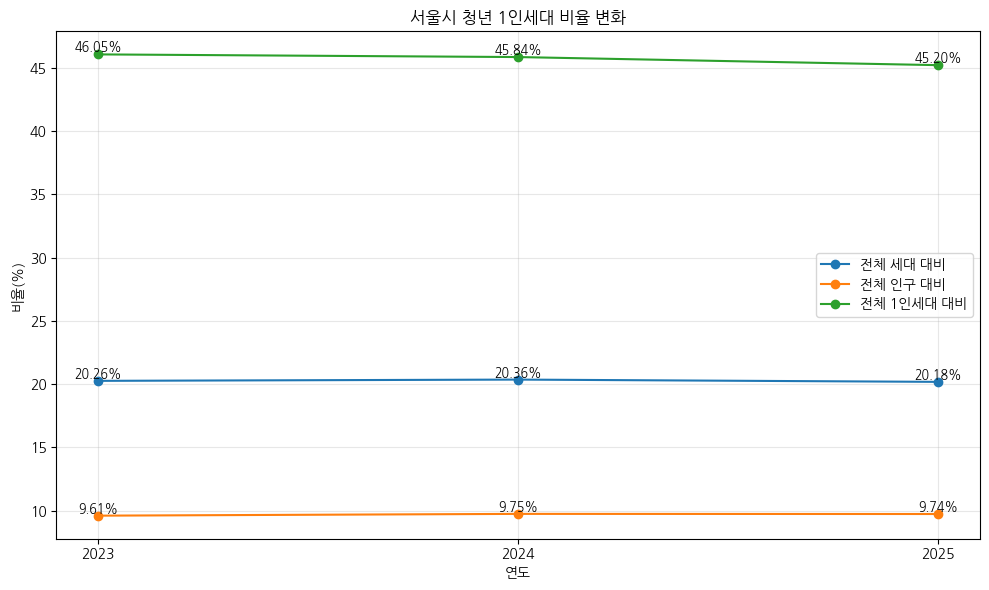

In [35]:
# ============================================
# 연도별 서울 전체 비율 변화
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    seoul_year_summary["연도"],
    seoul_year_summary[
        "전체세대대비_청년1인세대비율"
    ],
    marker="o",
    label="전체 세대 대비"
)

plt.plot(
    seoul_year_summary["연도"],
    seoul_year_summary[
        "전체인구대비_청년1인세대비율"
    ],
    marker="o",
    label="전체 인구 대비"
)

plt.plot(
    seoul_year_summary["연도"],
    seoul_year_summary[
        "전체1인세대대비_청년1인세대비율"
    ],
    marker="o",
    label="전체 1인세대 대비"
)

for _, row in seoul_year_summary.iterrows():
    for col in ratio_cols:
        plt.text(
            row["연도"],
            row[col],
            f'{row[col]:.2f}%',
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.title("서울시 청년 1인세대 비율 변화")
plt.xlabel("연도")
plt.ylabel("비율(%)")
plt.xticks([2023, 2024, 2025])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

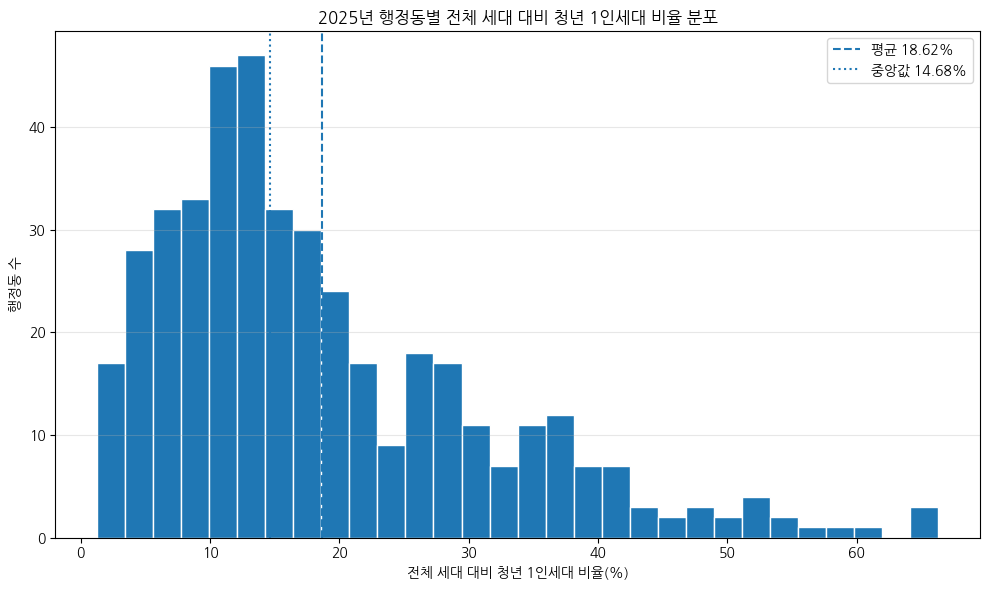

In [36]:
# ============================================
# 2025년 비율 분포
# ============================================

plot_2025 = final_2025.dropna(
    subset=[
        "전체세대대비_청년1인세대비율"
    ]
).copy()

mean_value = plot_2025[
    "전체세대대비_청년1인세대비율"
].mean()

median_value = plot_2025[
    "전체세대대비_청년1인세대비율"
].median()

plt.figure(figsize=(10, 6))

plt.hist(
    plot_2025[
        "전체세대대비_청년1인세대비율"
    ],
    bins=30,
    edgecolor="white"
)

plt.axvline(
    mean_value,
    linestyle="--",
    label=f"평균 {mean_value:.2f}%"
)

plt.axvline(
    median_value,
    linestyle=":",
    label=f"중앙값 {median_value:.2f}%"
)

plt.title("2025년 행정동별 전체 세대 대비 청년 1인세대 비율 분포")
plt.xlabel("전체 세대 대비 청년 1인세대 비율(%)")
plt.ylabel("행정동 수")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_491/3159107969.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


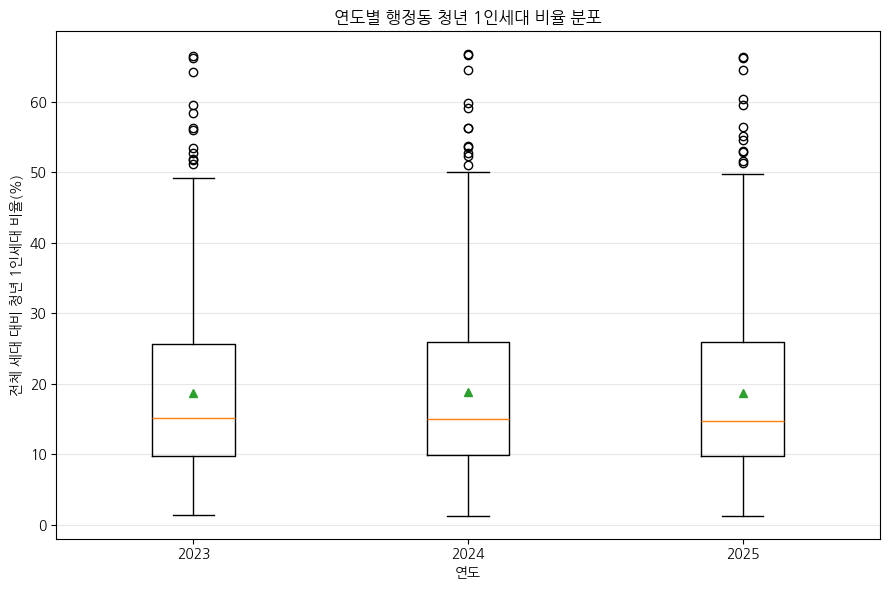

In [37]:
# ============================================
# 전체 세대 대비 비율 연도별 박스플롯
# ============================================

years = [2023, 2024, 2025]

box_data = [
    final_yearly.loc[
        final_yearly["연도"] == year,
        "전체세대대비_청년1인세대비율"
    ].dropna()
    for year in years
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    box_data,
    labels=years,
    showmeans=True
)

plt.title("연도별 행정동 청년 1인세대 비율 분포")
plt.xlabel("연도")
plt.ylabel("전체 세대 대비 청년 1인세대 비율(%)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

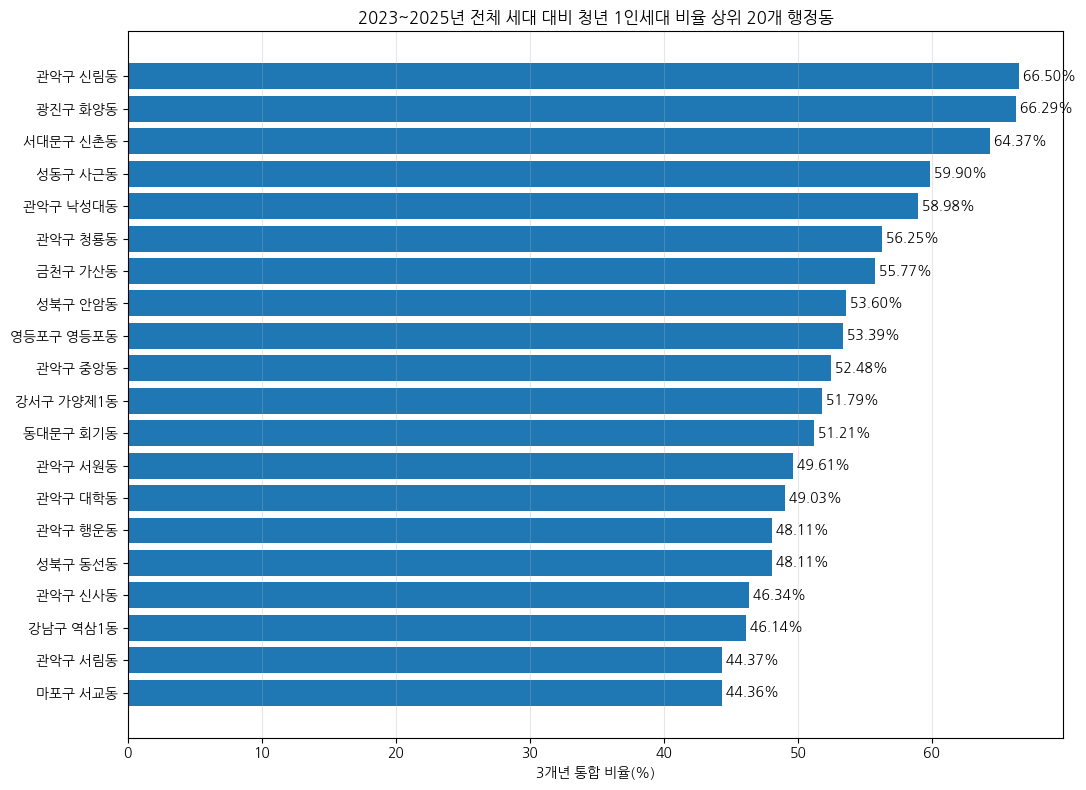

,행정기관코드,자치구,행정동,청년1인세대수_3개년합계,전체세대대비_청년1인세대비율_3개년,전체인구대비_청년1인세대비율_3개년,전체1인세대대비_청년1인세대비율_3개년
85,1162069500,관악구,신림동,37797,66.50,55.44,77.01
109,1121571000,광진구,화양동,35475,66.29,52.10,80.06
218,1141058500,서대문구,신촌동,28326,64.37,47.62,80.19
249,1120055000,성동구,사근동,14665,59.90,41.20,79.42
74,1162058500,관악구,낙성대동,21358,58.98,41.30,77.83
92,1162059500,관악구,청룡동,40872,56.25,38.27,76.36
126,1154551000,금천구,가산동,30530,55.77,41.09,71.28
271,1129060000,성북구,안암동,16068,53.60,35.48,74.43
343,1156053500,영등포구,영등포동,35091,53.39,38.17,69.76
91,1162061500,관악구,중앙동,16157,52.48,35.78,72.13


In [38]:
# ============================================
# 3개년 통합 비율 상위 20개 행정동
# ============================================

top_ratio = (
    final_3years_complete
    .dropna(
        subset=[
            "전체세대대비_청년1인세대비율_3개년"
        ]
    )
    .nlargest(
        20,
        "전체세대대비_청년1인세대비율_3개년"
    )
    .copy()
)

top_ratio["지역명"] = (
    top_ratio["자치구"]
    + " "
    + top_ratio["행정동"]
)

top_ratio = top_ratio.sort_values(
    "전체세대대비_청년1인세대비율_3개년"
)

plt.figure(figsize=(11, 8))

plt.barh(
    top_ratio["지역명"],
    top_ratio[
        "전체세대대비_청년1인세대비율_3개년"
    ]
)

for index, value in enumerate(
    top_ratio[
        "전체세대대비_청년1인세대비율_3개년"
    ]
):
    plt.text(
        value,
        index,
        f" {value:.2f}%",
        va="center"
    )

plt.title("2023~2025년 전체 세대 대비 청년 1인세대 비율 상위 20개 행정동")
plt.xlabel("3개년 통합 비율(%)")
plt.ylabel("")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

display(
    top_ratio[
        [
            "행정기관코드",
            "자치구",
            "행정동",
            "청년1인세대수_3개년합계",
            "전체세대대비_청년1인세대비율_3개년",
            "전체인구대비_청년1인세대비율_3개년",
            "전체1인세대대비_청년1인세대비율_3개년"
        ]
    ].sort_values(
        "전체세대대비_청년1인세대비율_3개년",
        ascending=False
    )
)

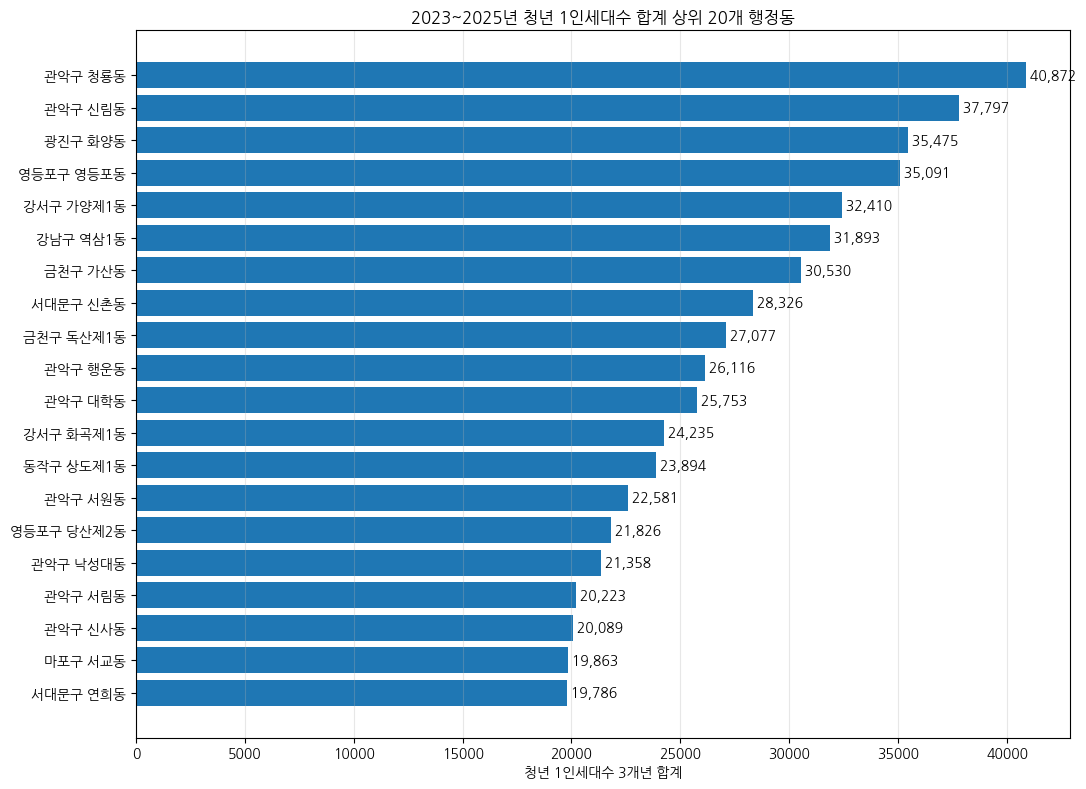

In [39]:
# ============================================
# 청년 1인세대 절대 규모 상위 20개
# ============================================

top_count = (
    final_3years_complete
    .nlargest(
        20,
        "청년1인세대수_3개년합계"
    )
    .copy()
)

top_count["지역명"] = (
    top_count["자치구"]
    + " "
    + top_count["행정동"]
)

top_count = top_count.sort_values(
    "청년1인세대수_3개년합계"
)

plt.figure(figsize=(11, 8))

plt.barh(
    top_count["지역명"],
    top_count["청년1인세대수_3개년합계"]
)

for index, value in enumerate(
    top_count["청년1인세대수_3개년합계"]
):
    plt.text(
        value,
        index,
        f" {value:,.0f}",
        va="center"
    )

plt.title("2023~2025년 청년 1인세대수 합계 상위 20개 행정동")
plt.xlabel("청년 1인세대수 3개년 합계")
plt.ylabel("")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

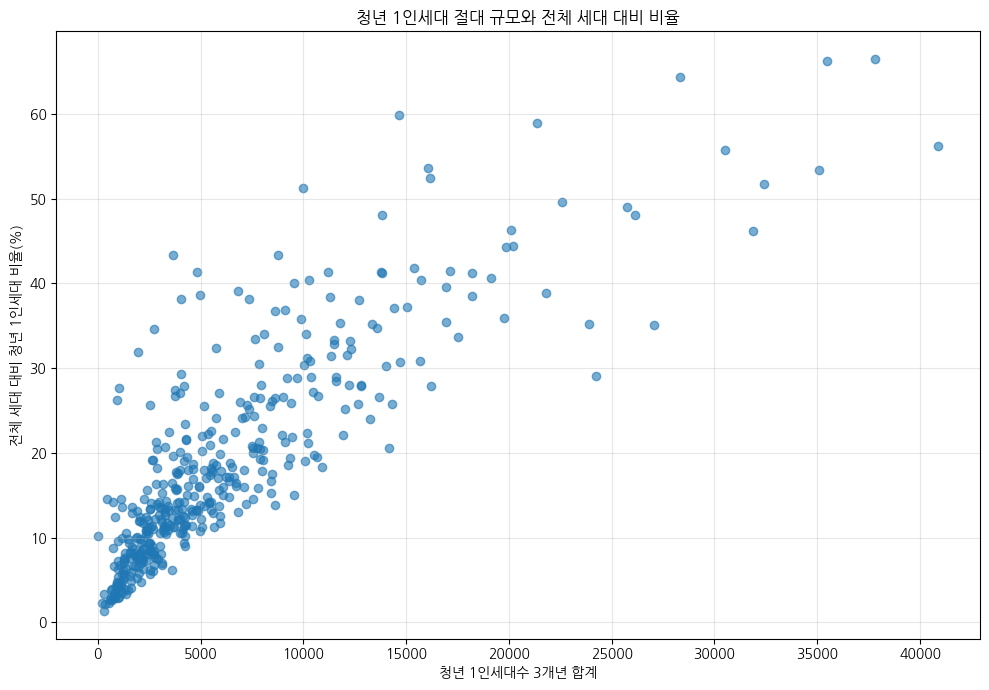

In [40]:
# ============================================
# 절대 규모와 비율 산점도
# ============================================

scatter_data = final_3years_complete.dropna(
    subset=[
        "청년1인세대수_3개년합계",
        "전체세대대비_청년1인세대비율_3개년"
    ]
).copy()

plt.figure(figsize=(10, 7))

plt.scatter(
    scatter_data["청년1인세대수_3개년합계"],
    scatter_data[
        "전체세대대비_청년1인세대비율_3개년"
    ],
    alpha=0.6
)

plt.title("청년 1인세대 절대 규모와 전체 세대 대비 비율")
plt.xlabel("청년 1인세대수 3개년 합계")
plt.ylabel("전체 세대 대비 청년 1인세대 비율(%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()